# Sample script for plotting a emagram

## Required packages
- matplotlib
- metpy
- numpy

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import metpy.calc as mpcalc
from metpy.units import units

from bsod2 import Sonde

In [28]:
ST_NAME = "St.4a"  # station name for labeling the plot
FILE_PATH = Path("Seisuimaru2407/raw_data/F2024061806S1101771.CSV")  # path to the raw data file for the station
data = Sonde(FILE_PATH,interp="p")

## Plot the emagram

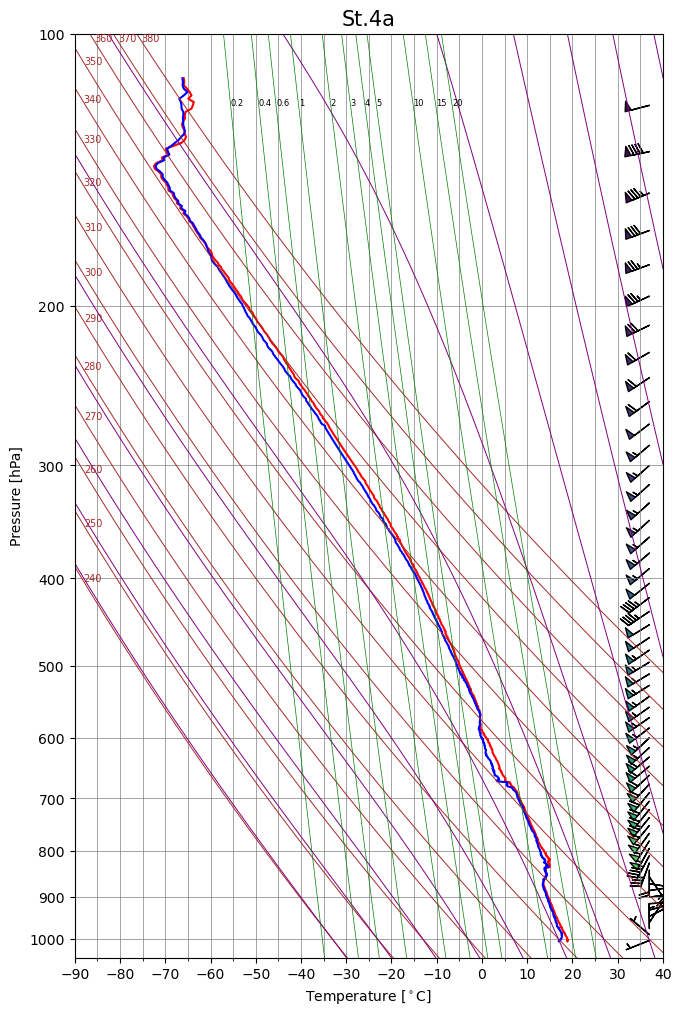

In [29]:
fig = plt.figure(figsize=(9, 12))
ax = fig.add_subplot(1, 1, 1)
ax.set_aspect(200)
ax.set_title(f"{ST_NAME}", fontsize=15)

# x axis(degC)
ax.set_xlabel(r"Temperature [$^\circ$C]")
ax.set_xlim(-90, 40)
ax.set_xticks(np.arange(-90, 41, 10))
ax.set_xticks(np.arange(-90, 41, 5), minor=True)

# y axis (pressure)
ax.set_ylabel("Pressure [hPa]")
ax.set_ylim(100, 1050)
ax.set_yscale("log")
ax.invert_yaxis()
ax.set_yticks(np.arange(100, 1100, 100))
ax.set_yticklabels([f"{int(p):d}" for p in np.arange(100, 1100, 100)])

ax.grid(True, which="both", linewidth=0.5, color="gray")

# plot the temperature profile
ax.plot(data.t, data.p, color="r")

# plot the dew point temperature profile
ax.plot(mpcalc.dewpoint_from_relative_humidity(data.t, data.rh), data.p, color="b")

# plot the dry adiabats
t0s = np.arange(240, 381, 10) * units("K")
plev = np.arange(50, 1101) * units.hPa
for i in range(t0s.shape[0]):
    t0 = t0s[i]
    dry_l = mpcalc.dry_lapse(plev, t0, 1000 * units.hPa).to("degC")
    ax.plot(dry_l, plev, c="brown", linewidth="0.7")
    label_i = np.abs(dry_l - -88 * units("degC")).argmin()
    if plev[label_i] > 100.0 * units.hPa:
        ax.text(
            dry_l[label_i],
            plev[label_i],
            f"{int(t0.m)}",
            fontsize=7,
            color="brown",
        )
    else:
        label_i = np.abs(plev - 102 * units.hPa).argmin()
        ax.text(
            dry_l[label_i],
            plev[label_i],
            f"{int(t0.m)}",
            fontsize=7,
            color="brown",
        )

# plot the moist adiabats
t0s = np.arange(240, 361, 10) * units("K")
plev = np.arange(50, 1101) * units.hPa
for i in range(t0s.shape[0]):
    t0 = t0s[i]
    moist_l = mpcalc.moist_lapse(plev, t0, 1000 * units.hPa).to("degC")
    ax.plot(moist_l, plev, c="purple", linewidth="0.7")

# plot the saturation mixing ratio lines
for sat_mixr in [0.2,0.4,0.6,1,2,3,4,5,10,15,20,]:
    tmp = np.arange(-90,41,0.01)
    prs = 6.11*(sat_mixr+622)/sat_mixr*np.exp(19.84*tmp/(tmp+273.15)+1e-5)
    ax.plot(tmp,prs,c="g",lw=0.5)
    i = np.abs(prs - 120).argmin()
    ax.text(tmp[i],prs[i],f"{sat_mixr}",fontsize=6)

# plot wind barbs
u,v = mpcalc.wind_components(data.ws, data.wd)
SKIP = 15
ax.barbs(
    np.full((len(data)), 37)[::SKIP],
    data.p[::SKIP],
    u.to("kt")[::SKIP],
    v.to("kt")[::SKIP],
    data.p[::SKIP],
    length=6,
    barb_increments={"half": 5, "full": 10, "flag": 50},
    color="k",
    )

plt.show()